# Hierarchical forecasting I with `numpyro_forecast`

This notebook ports the blog post [**Hierarchical forecasting with NumPyro (part I)**](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. We forecast hourly **BART arrivals to a single destination** (`EMBR`, Embarcadero) from all origin stations: 50 series sharing global hyperparameters, each with its own random-walk level and weekly seasonality, under a single Normal observation scale.

We subclass `numpyro_forecast.ForecastingModel` and let `Forecaster` handle the *fit-once / forecast-any-horizon* mechanics. Visualizations use **ArviZ >= 1.0** (`az.hdi` + `fill_between`).

> **Note on reproducibility.** We match the blog's data, seed, optimizer and step counts. Results reproduce the blog's behavior and CRPS magnitude but are not bit-for-bit identical: the forecast horizon uses the package's separate-`_future`-site mechanism rather than re-running the guide over the full covariates.

## Prepare notebook

In [1]:
from typing import cast

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from jax import random
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast.datasets import load_bart_hierarchical
from numpyro_forecast.evaluate import eval_crps
from numpyro_forecast.forecaster import Forecaster, ForecastingModel
from numpyro_forecast.typing import Array
from numpyro_forecast.util import periodic_repeat

numpyro.set_host_device_count(n=4)
plt.rcParams["figure.figsize"] = (10, 4)

rng_key = random.PRNGKey(seed=42)
period = 24 * 7  # weekly seasonality (hours)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read data

We load the windowed origin-destination panel (`log1p` counts, 90 training days + 2 test weeks) and select arrivals to `EMBR` from every origin. This yields a `(time, n_series)` array where each of the 50 origins is a series and time is at axis `-2` (the observation/series dimension is `-1`).

data shape: (2496, 50) | split: 2160


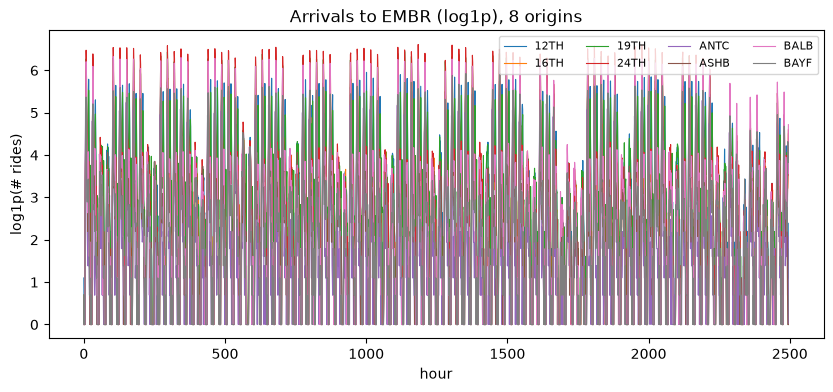

In [2]:
y_full, split, stations = load_bart_hierarchical()
embr = stations.index("EMBR")
data = jnp.swapaxes(y_full[:, :, embr], 0, 1)  # (time, n_series)
n_series = data.shape[-1]
print("data shape:", data.shape, "| split:", split)

fig, ax = plt.subplots()
for i in range(8):
    ax.plot(np.asarray(data[:, i]), lw=0.8, label=stations[i])
ax.legend(ncol=4, fontsize=8)
ax.set(title="Arrivals to EMBR (log1p), 8 origins", xlabel="hour", ylabel="log1p(# rides)");

## Train-test split

The last two weeks (`336` hours) are held out for testing. Covariates are dummy zeros (seasonality is modelled internally); only their shape is used.

In [3]:
T0 = 0
T1 = split  # 2160
T2 = data.shape[0]  # 2496

y_train = data[T0:T1]
y_test = data[T1:T2]
covariates = jnp.zeros((T2, n_series))
covariates_train = covariates[T0:T1]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

# Christmas anomaly index (BART series starts 2011-01-01, hourly).
dates = pd.date_range("2011-01-01", periods=78_888, freq="h")[-T2:]
christmas = np.flatnonzero((dates.month == 12) & (dates.day == 25))
christmas_index = int(christmas[0]) if len(christmas) else None
print("christmas index:", christmas_index)

train: (2160, 50) test: (336, 50)
christmas index: 2328


## Model specification

Each series $s$ has its own random-walk level $\ell_{t,s}$ and weekly seasonal profile, sharing global hyperparameters and a single observation scale:

$$
\mu_{t,s} = \ell_{t,s} + \text{seasonal}_{(t \bmod \text{period}),\,s},\qquad \ell_{t,s} = \ell_{t-1,s} + \delta_{t,s},
$$
$$
y_{t,s} \sim \mathcal{N}(\mu_{t,s}, \sigma).
$$

We wrap `self.time_series(...)` in an `n_series` plate so the drift (and its forecast `_future` companion) is per-series; the weekly seasonal lives under the `n_series` and `hour_of_week` plates and is tiled with `periodic_repeat`.

In [4]:
class MultiSeriesForecaster(ForecastingModel):
    """Per-series local level + weekly seasonality with a shared Normal scale."""

    def __init__(self, period: int = 24 * 7) -> None:
        super().__init__()
        self.period = period

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the multi-series forecasting model."""
        n_series = covariates.shape[-1]
        duration = covariates.shape[-2]

        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
        centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

        with numpyro.plate("n_series", n_series, dim=-1):
            drift = self.time_series(
                "drift",
                lambda: dist.Normal(0.0, drift_scale),
                reparam=LocScaleReparam(centered=centered),
            )
            with numpyro.plate("hour_of_week", self.period, dim=-2):
                seasonal = cast("Array", numpyro.sample("seasonal", dist.Normal(0.0, 5.0)))

        level = jnp.cumsum(drift, axis=-2)
        prediction = level + periodic_repeat(seasonal, duration, axis=-2)

        self.predict(dist.Normal(0.0, sigma), prediction)

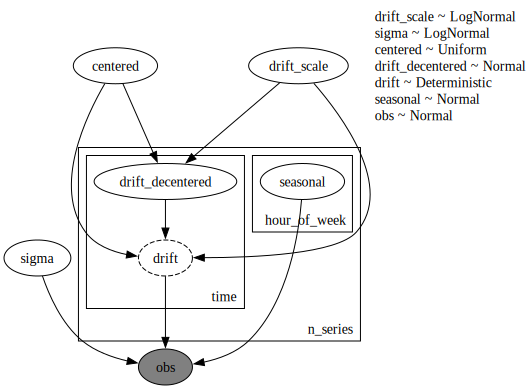

In [5]:
numpyro.render_model(
    MultiSeriesForecaster(period=period),
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

We draw from the prior over the training window and overlay 50% / 94% HDI bands on the last three weeks of training data for eight origins.

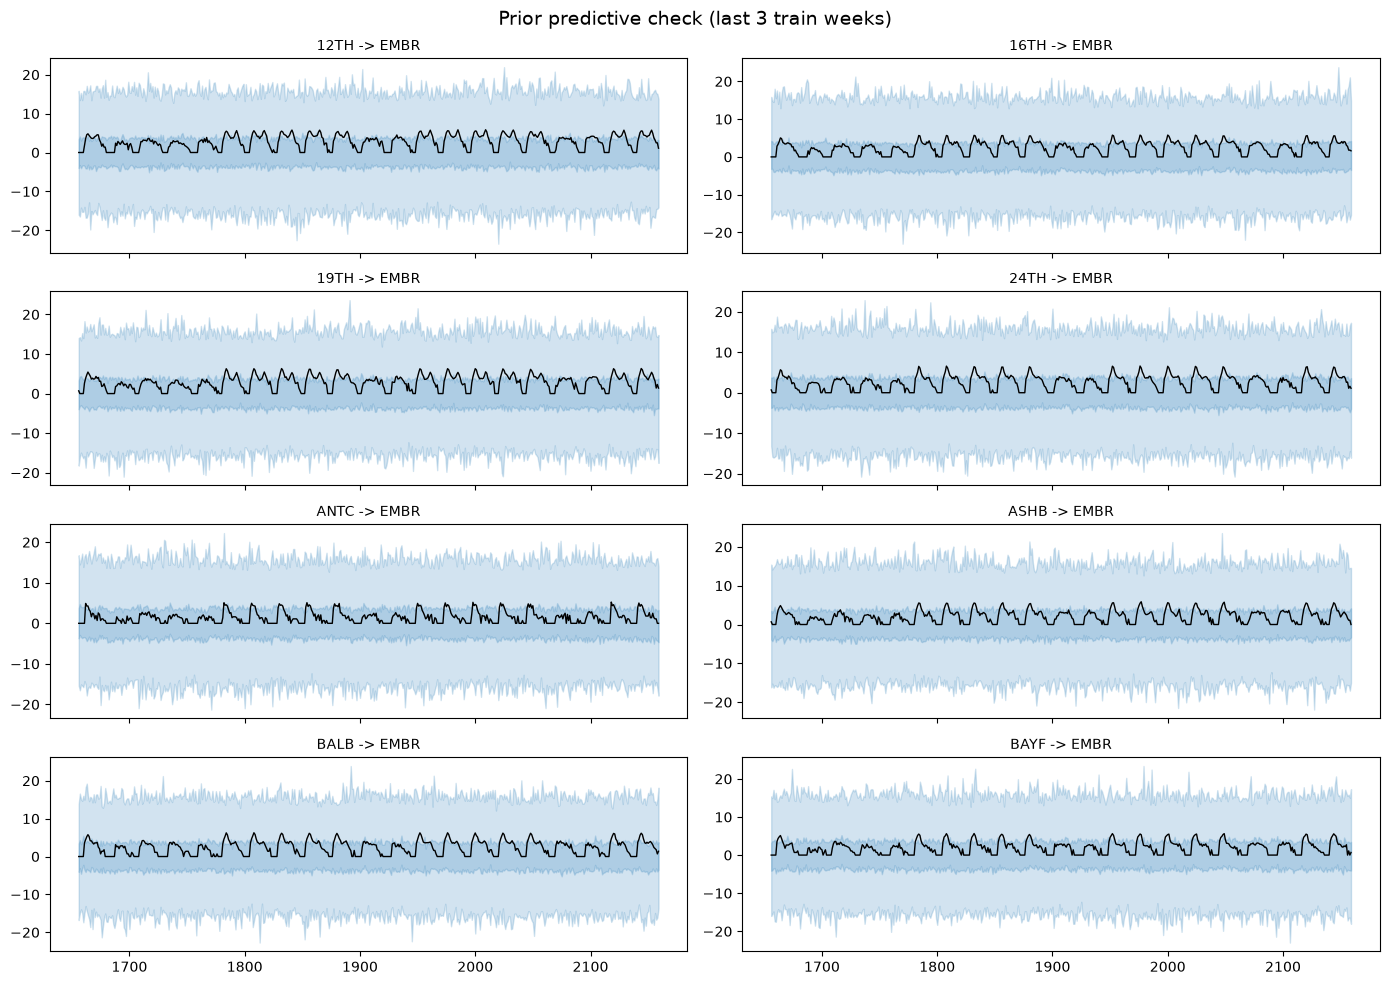

In [6]:
def hdi_bounds(samples: Array | np.ndarray, prob: float) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(samples)
    da = xr.DataArray(arr[None], dims=["chain", "draw", "time"])
    band = az.hdi(da, prob=prob)
    return band.sel(ci_bound="lower").values, band.sel(ci_bound="upper").values


prior_predictive = Predictive(
    MultiSeriesForecaster(period=period), num_samples=2_000, return_sites=["obs"]
)
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"]

lo = T1 - 3 * period  # last three weeks of train
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 10), sharex=True)
for i, ax in enumerate(axes.ravel()):
    for prob in [0.94, 0.5]:
        lower, upper = hdi_bounds(prior_obs[:, lo:T1, i], prob)
        ax.fill_between(time_train[lo:T1], lower, upper, color="C0", alpha=0.2)
    ax.plot(time_train[lo:T1], np.asarray(y_train[lo:T1, i]), color="black", lw=1)
    ax.set_title(f"{stations[i]} -> EMBR", fontsize=10)
fig.suptitle("Prior predictive check (last 3 train weeks)", fontsize=14)
fig.tight_layout();

## Inference with SVI

`Forecaster` fits the model with SVI (`AutoNormal` guide, `Adam`).

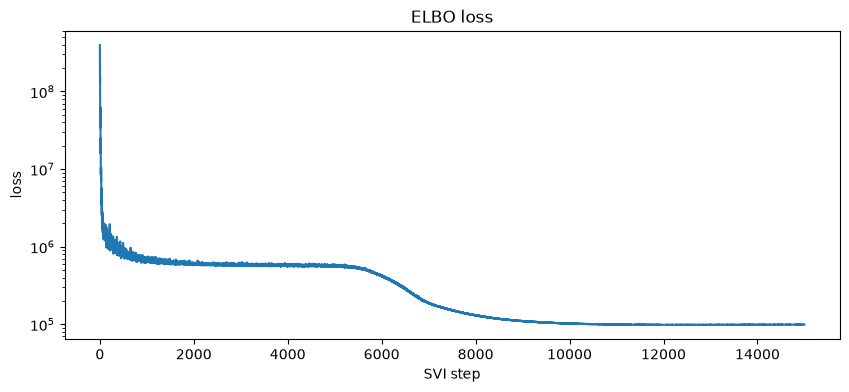

In [7]:
rng_key, rng_subkey = random.split(rng_key)
model = MultiSeriesForecaster(period=period)
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optim=Adam(step_size=0.05),
    num_steps=15_000,
    rng_key=rng_subkey,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set_yscale("log")
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

In-sample posterior predictive over the train window plus the forecast over the test horizon. We clip predictions at zero (the `log1p` scale is non-negative) before scoring with CRPS.

In [8]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)

posterior_samples = forecaster.guide.sample_posterior(
    key_post, forecaster.params, sample_shape=(1_500,)
)
train_pp = Predictive(model, posterior_samples=posterior_samples, return_sites=["obs"])(
    key_pp, covariates_train
)["obs"]

forecast = forecaster(y_train, covariates, num_samples=1_500, rng_key=key_fc)

train_pp = jnp.clip(train_pp, min=0.0)
forecast = jnp.clip(forecast, min=0.0)

crps_train = eval_crps(train_pp, y_train)
crps_test = eval_crps(forecast, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")

Train CRPS: 0.2077
Test CRPS:  0.3676


## Forecast visualization

Eight origins -> `EMBR`: in-sample posterior predictive (blue, last 3 train weeks) and forecast (orange) with 50% / 94% HDI bands, the train/test split, the Christmas anomaly, and the observed series.

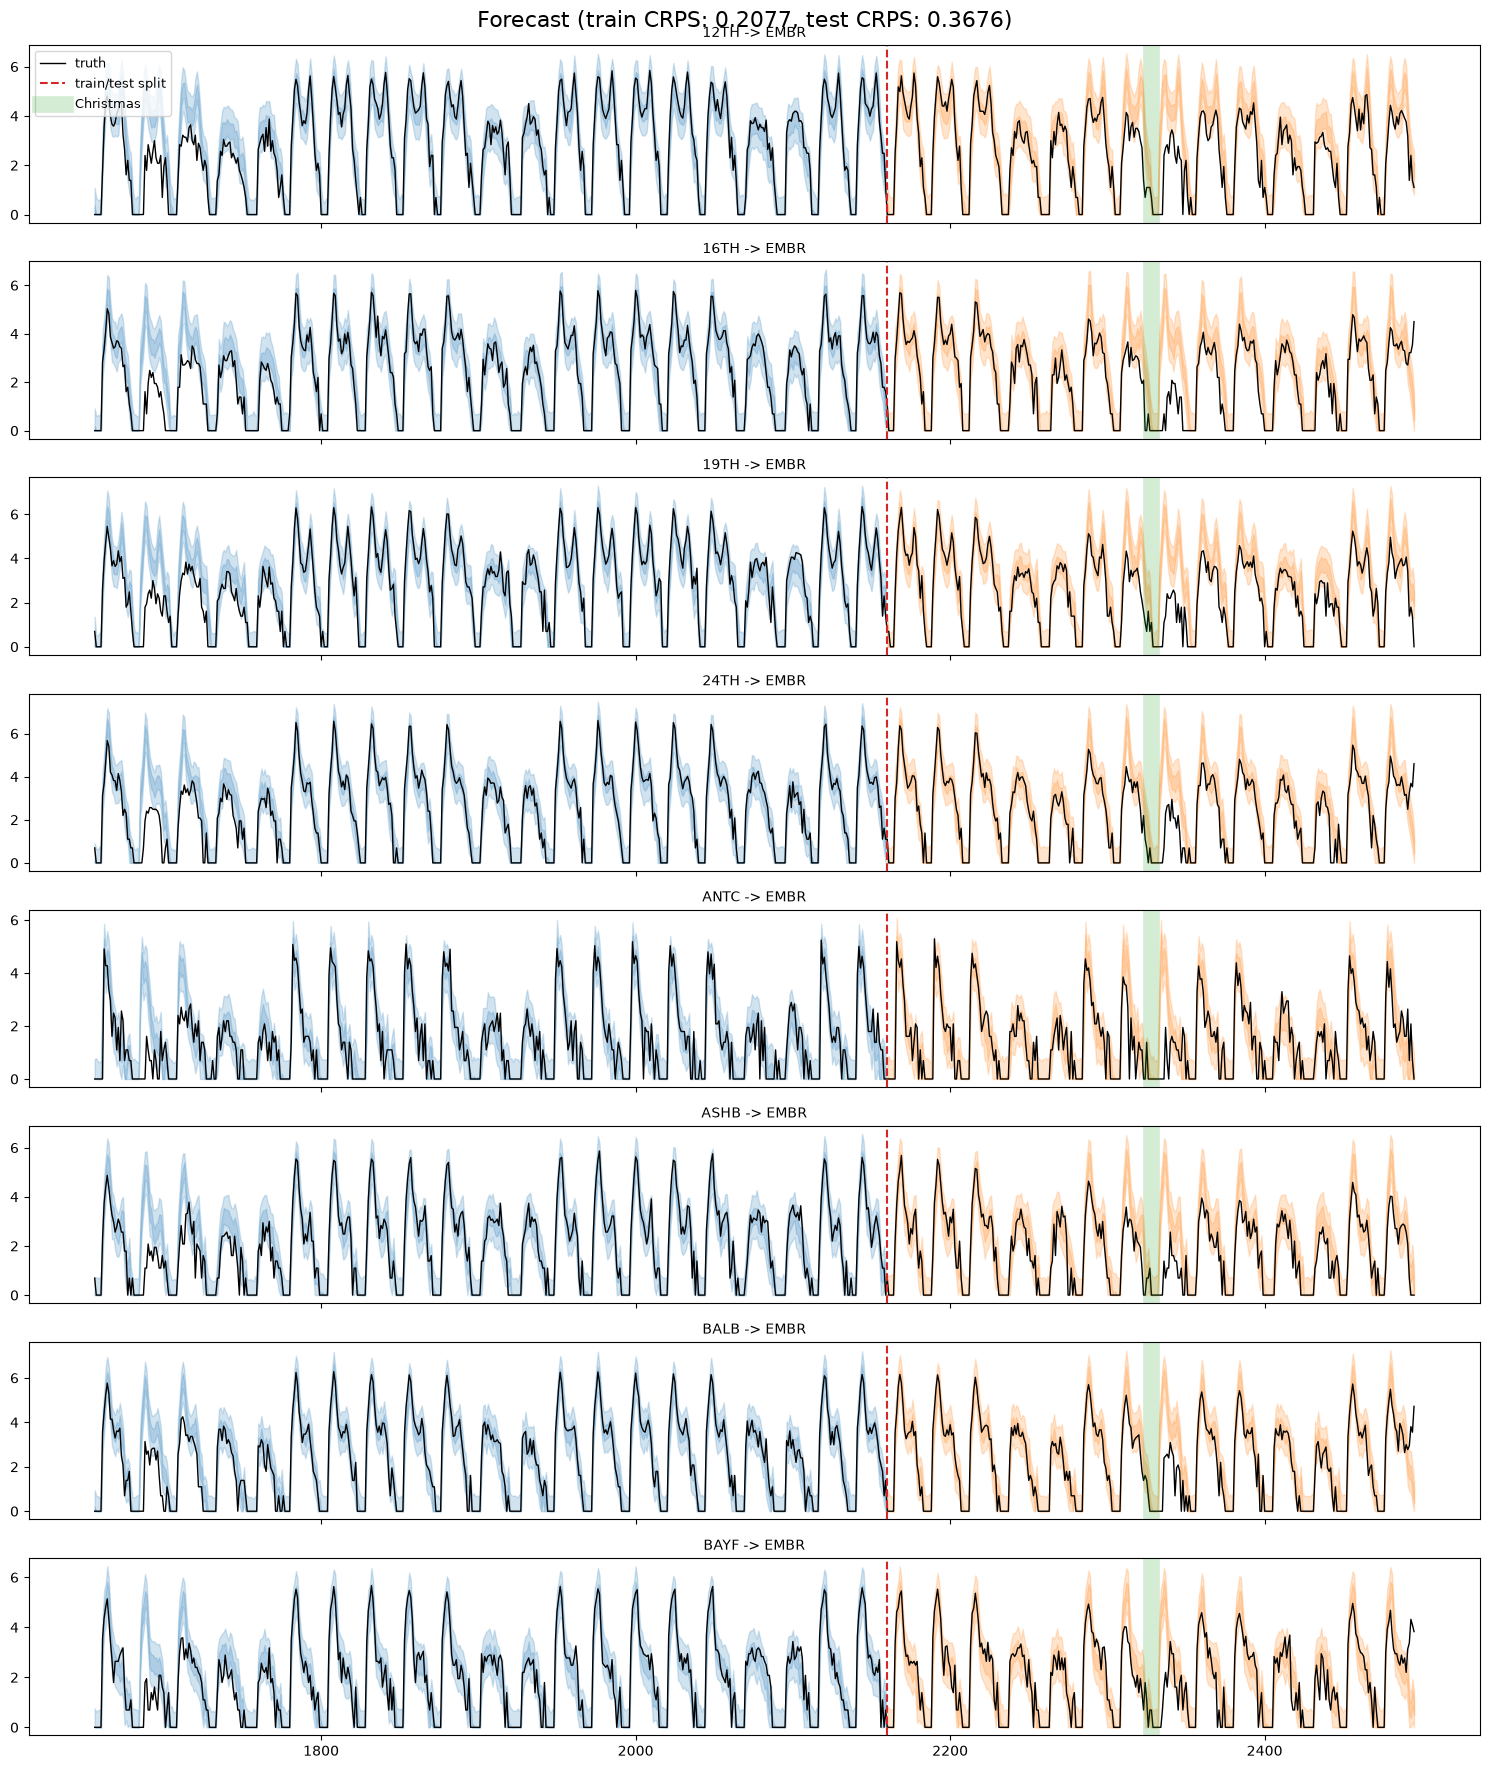

In [9]:
fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(15, 18), sharex=True)
for i, ax in enumerate(axes):
    for prob in [0.94, 0.5]:
        lower, upper = hdi_bounds(train_pp[:, lo:T1, i], prob)
        ax.fill_between(time_train[lo:T1], lower, upper, color="C0", alpha=0.2)
        lower, upper = hdi_bounds(forecast[:, :, i], prob)
        ax.fill_between(time_test, lower, upper, color="C1", alpha=0.2)
    ax.plot(time[lo:T2], np.asarray(data[lo:T2, i]), color="black", lw=1, label="truth")
    ax.axvline(T1, color="C3", ls="--", label="train/test split")
    if christmas_index is not None:
        ax.axvline(christmas_index, color="C2", lw=12, alpha=0.2, label="Christmas")
    ax.set_title(f"{stations[i]} -> EMBR", fontsize=10)
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle(
    f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    fontsize=16,
)
fig.tight_layout();